# ✅ Step 1: Introduction & Dataset Loading

## Credit Card Fraud Detection

This project focuses on detecting fraudulent credit card transactions using machine learning techniques.

### Dataset Information:
- **Source**: [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Description**: Contains transactions made by European cardholders in September 2013.
- **Features**: 31 columns (28 anonymized `V1` to `V28`, plus `Time`, `Amount`, and `Class`)
- **Target Variable**: `Class` — 0 (Genuine) or 1 (Fraudulent)

### Objective:
- Preprocess and normalize the data.
- Handle class imbalance.
- Train models to accurately detect fraud.
- Evaluate using precision, recall, F1-score, and ROC-AUC.


# ***SYSTEM ARCHITECTURE:***

>



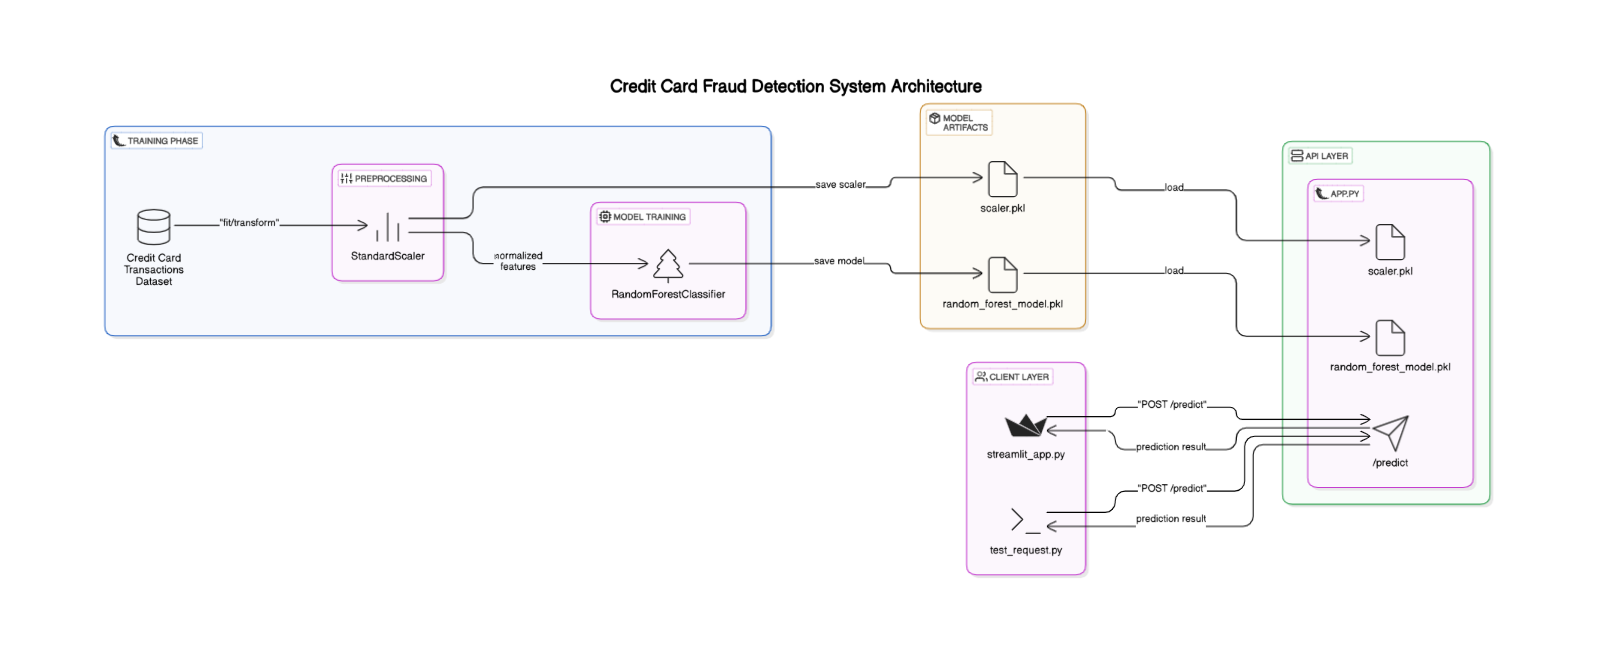

In [ ]:
!rm -rf ~/.kaggle

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nusrath1729","key":"44826cbc5ba5bd7d38c7dfaa4037d5d1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


LOAD THE DATASET

In [ ]:

import pandas as pd
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


📌 Check Dataset Overview

In [ ]:
print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Shape of dataset: (284807, 31)

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class  

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


# ✅ Step 2: Data Exploration & Visualization

2.1 – Summary Statistics

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

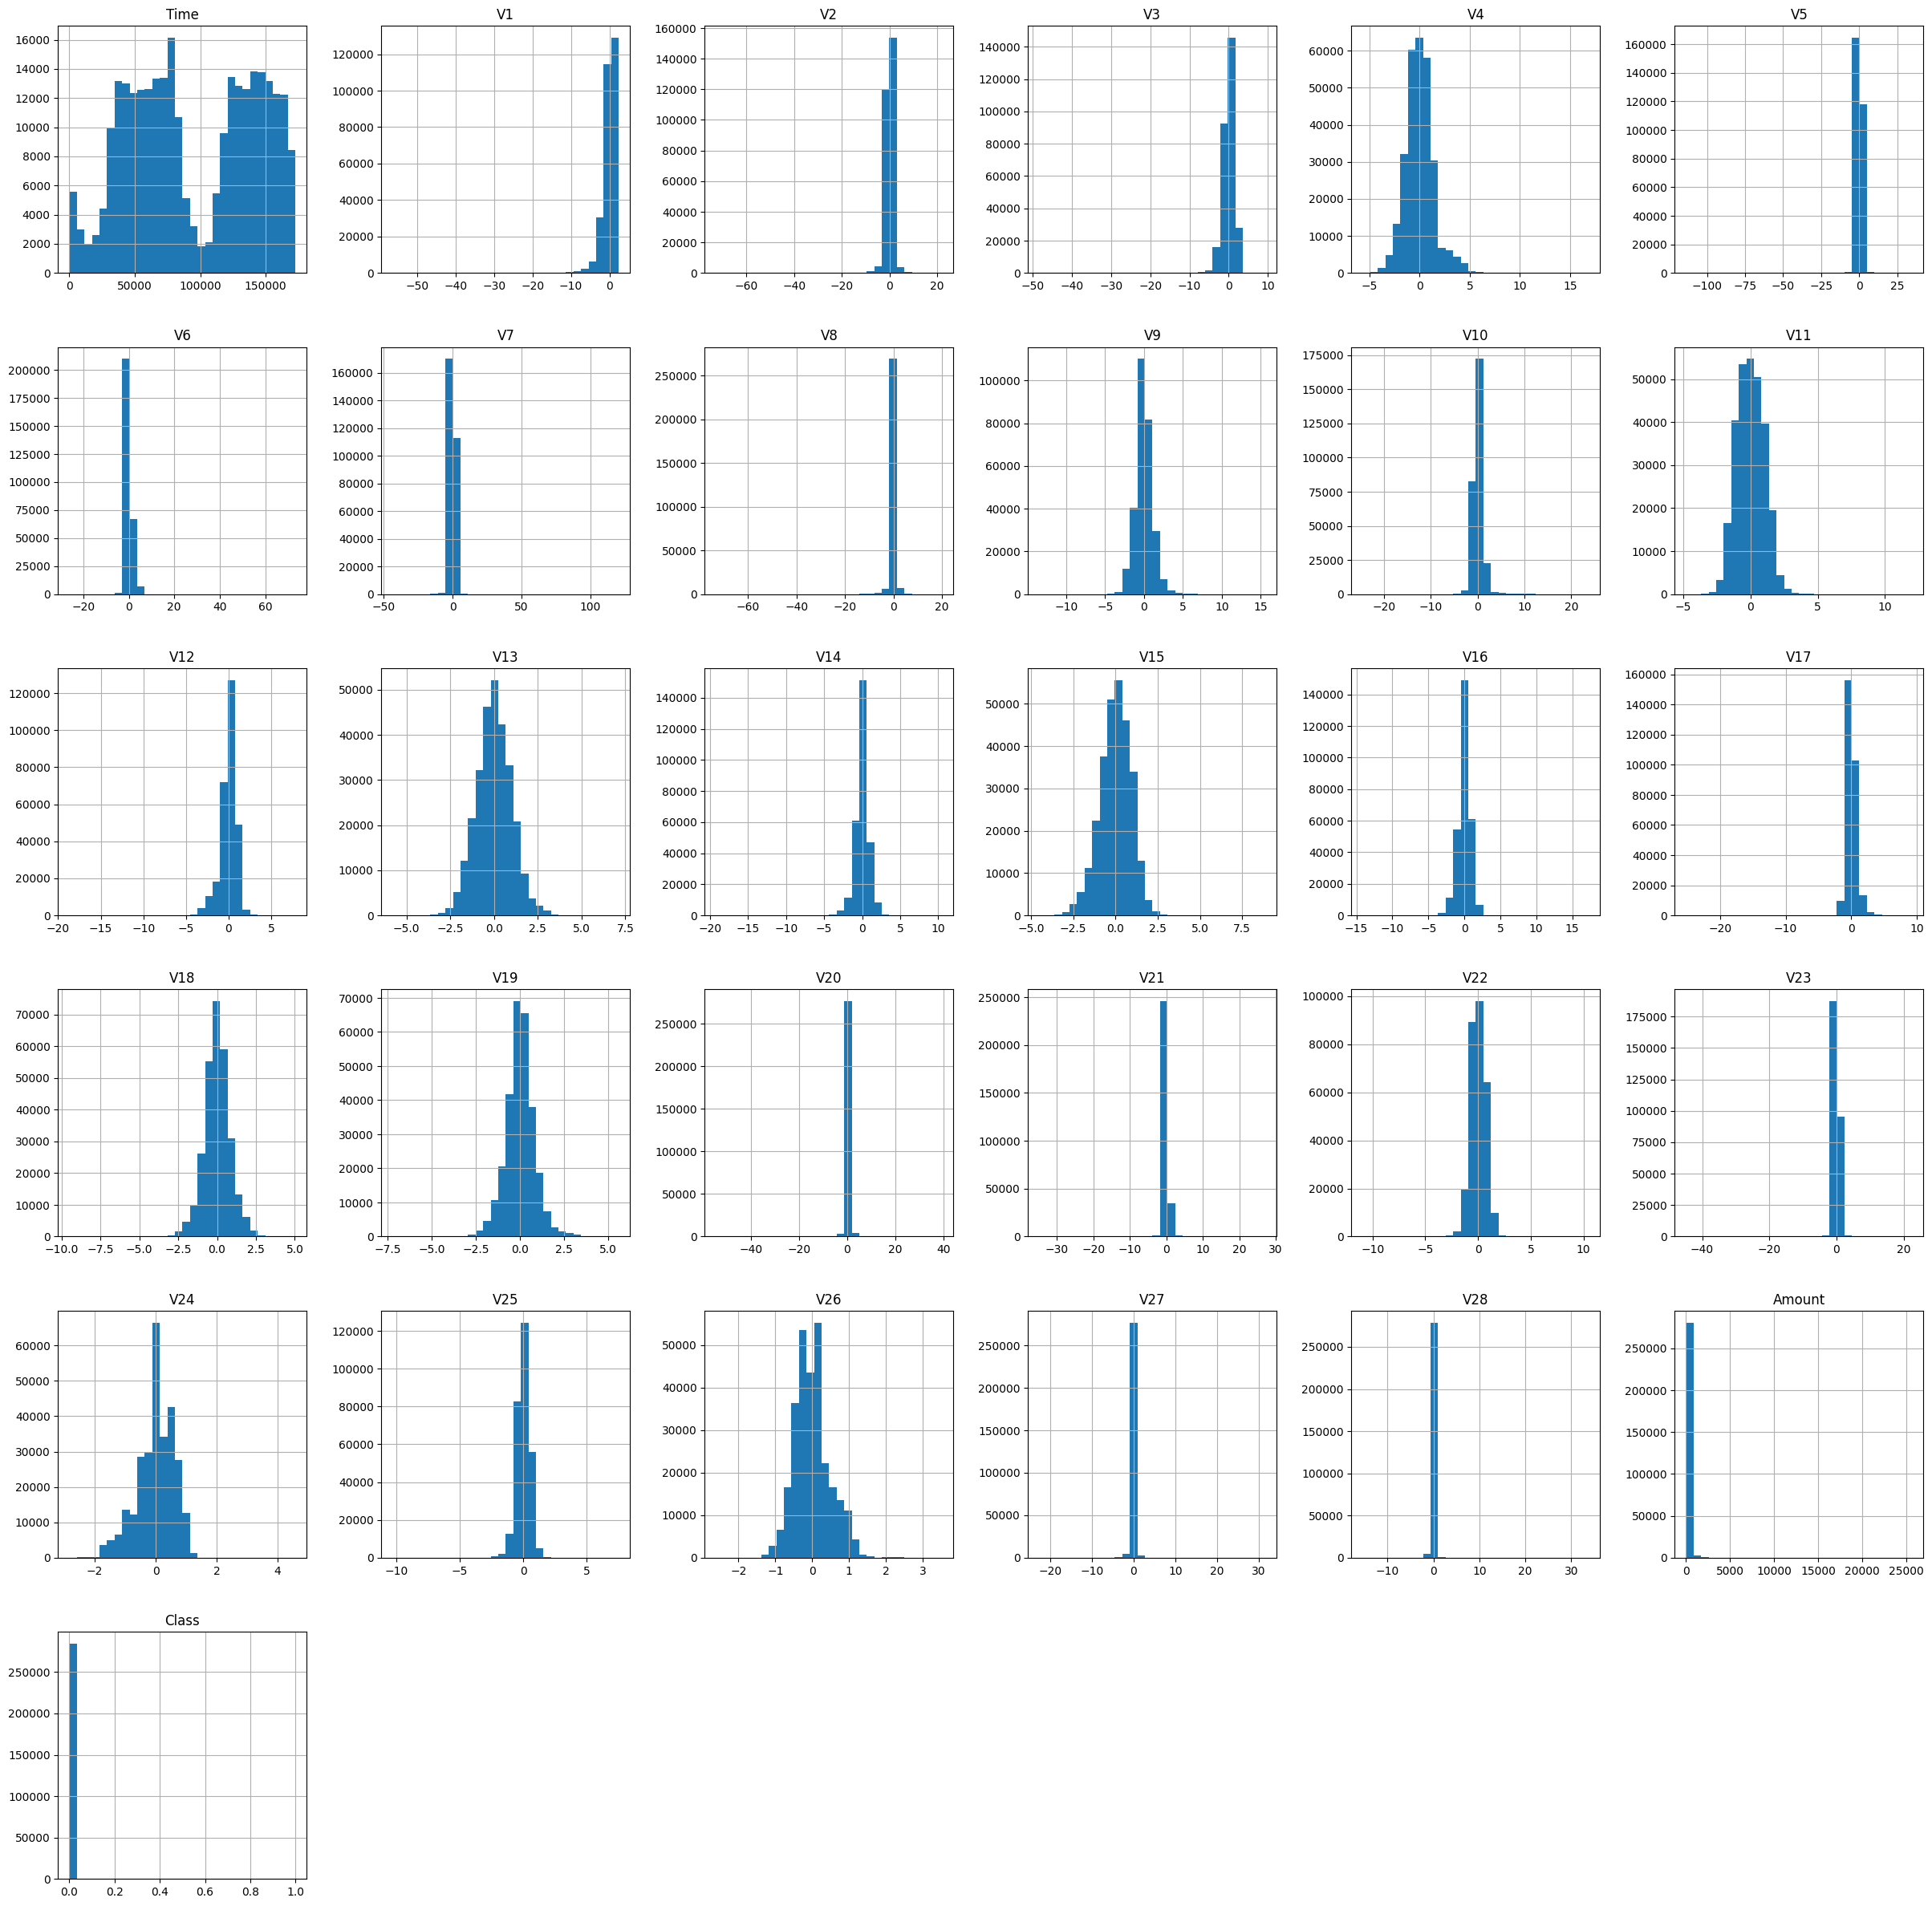

In [ ]:
df.hist(bins=30,figsize=(30,30))

2.2 – Class Distribution Visualization

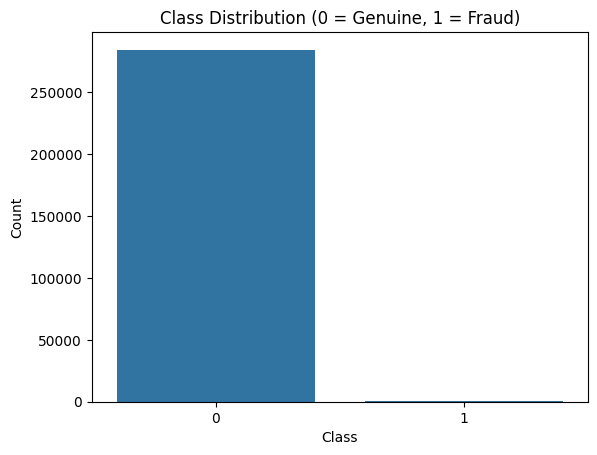

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


# ✅ Step 3: Preprocessing

3.1 – Feature Scaling

In [ ]:
#pre-processing data
from sklearn.preprocessing import RobustScaler
new_df = df.copy()
new_df["Amount"] = RobustScaler().fit_transform(new_df["Amount"].to_numpy().reshape(-1,1))

time = new_df['Time']
new_df['Time'] = (time - time.min()) / (time.max() - time.min())
new_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0
2,0.000006,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0
3,0.000006,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0
4,0.000012,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,0.999965,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.296653,0
284803,0.999971,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0.038986,0
284804,0.999977,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0.641096,0
284805,0.999977,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.167680,0


In [ ]:
new_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,0.548717,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,0.927124,0.001727
std,0.274828,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,3.495006,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,-0.307413,0.000000
25%,0.313681,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,-0.229162,0.000000
50%,0.490138,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000,0.000000
75%,0.806290,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.770838,0.000000
max,1.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,358.683155,1.000000


3.2 – Train-Test Split

In [ ]:

new_df = new_df.sample(frac=1,random_state=1)

Data Preprocessing and Three-Way Split (Train, Test, Validation)

In [ ]:
train ,test ,val = new_df[:240000],new_df[240000:262000], new_df[262000:]
train['Class'].value_counts() ,test['Class'].value_counts(),val['Class'].value_counts()

(Class
 0    239589
 1       411
 Name: count, dtype: int64,
 Class
 0    21955
 1       45
 Name: count, dtype: int64,
 Class
 0    22771
 1       36
 Name: count, dtype: int64)

In [ ]:
train_np = train.to_numpy()
test_np = test.to_numpy()
val_np = val.to_numpy()

train_np.shape,test_np.shape,val_np.shape

((240000, 31), (22000, 31), (22807, 31))

In [ ]:
x_train,y_train = train_np[:,:-1],train_np[:,-1]
x_test,y_test = test_np[:,:-1],test_np[:,-1]
x_val,y_val = val_np[:,:-1],val_np[:,-1]
x_train.shape,y_train.shape,x_test.shape,y_test.shape,x_val.shape,y_val.shape

((240000, 30), (240000,), (22000, 30), (22000,), (22807, 30), (22807,))

# ✅ Step 4: Handling Class Imbalance

Fraud cases are less than 0.2% of the total dataset. Training on such imbalanced data can make the model biased toward the majority class (genuine).

We'll use SMOTE (Synthetic Minority Over-sampling Technique) to balance the training set.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply only to training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_res))


Before SMOTE: Counter({np.float64(0.0): 239589, np.float64(1.0): 411})
After SMOTE: Counter({np.float64(0.0): 239589, np.float64(1.0): 239589})


After Balancing

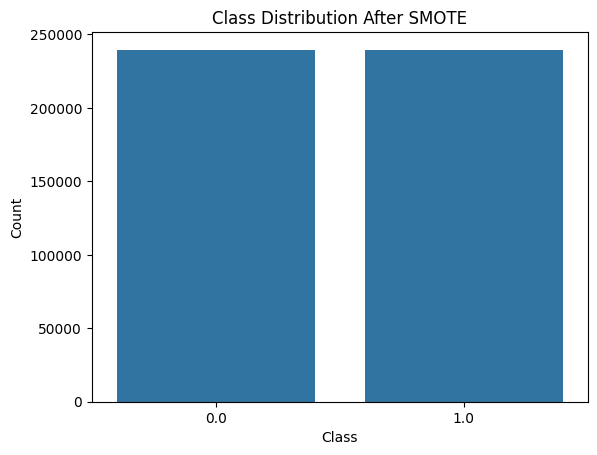

In [ ]:
import seaborn as sns
sns.countplot(x=y_train_res)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


#  ✅ Step 5: Model Training & Evaluation

✔️ Model Used: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train,y_train)
logistic_model.score(x_test,y_test)

0.9991363636363636

✔️ Evaluation Metrics

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_val,logistic_model.predict(x_val),target_names = ['Not Fraud', 'Fraud']))


              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     22771
       Fraud       0.83      0.56      0.67        36

    accuracy                           1.00     22807
   macro avg       0.92      0.78      0.83     22807
weighted avg       1.00      1.00      1.00     22807



✔️ Model Used:  Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint



shallow_nn = Sequential()
shallow_nn.add(InputLayer((x_train.shape[1],)))
shallow_nn.add(Dense(2,'relu'))
shallow_nn.add(BatchNormalization())
shallow_nn.add(Dense(1,'sigmoid'))

checkpoint =  ModelCheckpoint('shallow_nn.h5',save_best_only=True)
shallow_nn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
shallow_nn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │            62 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 69 (276.00 B)

 Non-trainable params: 4 (16.00 B)

In [ ]:
shallow_nn.fit(x_train,y_train,epochs=5,validation_data=(x_val,y_val),callbacks=[checkpoint])

Epoch 1/5
7469/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0030

7500/7500 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0070
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9993 - loss: 0.0031 - val_accuracy: 0.9990 - val_loss: 0.0084
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9991 - val_loss: 0.0085
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9991 - val_loss: 0.0086
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9991 - val_loss: 0.0099


In [ ]:
shallow_nn.predict(x_train)

7500/7500 ━━━━━━━━━━━━━━━━━━━━ 6s 730us/step


array([[1.5428670e-04],
       [1.1313878e-04],
       [1.0947980e-04],
       ...,
       [2.5759955e-05],
       [1.6481834e-04],
       [3.4851453e-04]], dtype=float32)

In [ ]:
def neural_net_prediction(model,x):

  return (shallow_nn.predict(x).flatten() > 0.5).astype(int)

neural_net_prediction(shallow_nn,x_val)

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([0, 0, 0, ..., 0, 0, 0])

✔️ Evaluation Metrics -neural networks

In [ ]:
print(classification_report(y_val,neural_net_prediction(shallow_nn,x_val),target_names = ['Not Fraud', 'Fraud']))

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     22771
       Fraud       0.69      0.75      0.72        36

    accuracy                           1.00     22807
   macro avg       0.85      0.87      0.86     22807
weighted avg       1.00      1.00      1.00     22807



✔️ Model Used: Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth = 2 ,n_jobs = -1)
rf.fit(x_train,y_train)
rf.score(x_test,y_test)

print(classification_report(y_val,rf.predict(x_val),target_names = ['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     22771
       Fraud       0.81      0.47      0.60        36

    accuracy                           1.00     22807
   macro avg       0.90      0.74      0.80     22807
weighted avg       1.00      1.00      1.00     22807



# ✅ STEP -6 HANDLING IMBALANCED DATA EFFICIENTLY

:

🔍 Class Distribution: Separating Fraud and Non-Fraud Transactions


In [ ]:
frauds = new_df.query('Class == 1')
non_frauds = new_df.query('Class == 0')

non_frauds['Class'].value_counts(), frauds['Class'].value_counts()

(Class
 0    284315
 Name: count, dtype: int64,
 Class
 1    492
 Name: count, dtype: int64)

In [ ]:
balanced_df = pd.concat([frauds,non_frauds.sample(len(frauds))])
balanced_df['Class'].value_counts()

,count
Class,
1,492
0,492


In [ ]:
balanced_df = balanced_df.sample(frac=1, random_state=1)
balanced_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
39799,0.231324,-0.753643,1.359414,-0.141718,0.925611,0.616216,-0.796395,0.488047,0.364895,-0.637738,...,-0.005217,-0.102081,-0.191232,-0.580273,-0.087538,-0.297482,0.294915,0.139379,-0.125900,0
96341,0.380388,1.227614,-0.668974,-0.271785,-0.589440,-0.604795,-0.350285,-0.486365,-0.010809,-0.794944,...,-0.026055,-0.295255,-0.180459,-0.436539,0.494649,-0.283738,-0.001128,0.035075,1.062111,1
248296,0.890522,-0.613696,3.698772,-5.534941,5.620486,1.649263,-2.335145,-0.907188,0.706362,-3.747646,...,0.319261,-0.471379,-0.075890,-0.667909,-0.642848,0.070600,0.488410,0.292345,-0.307413,1
152500,0.563649,2.103489,0.359436,-2.627092,0.194789,1.271083,-0.730883,0.544563,-0.378992,1.378598,...,-0.074984,0.225323,-0.098366,0.128774,0.507369,0.210746,-0.095038,-0.066866,-0.257668,0
12642,0.128229,-1.634885,1.365071,1.437039,1.901877,-1.340010,1.092228,-0.364416,0.875921,1.712336,...,-0.366880,-0.531644,0.199186,0.041811,-0.381985,-0.514514,-0.472912,-0.021977,1.121358,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78233,0.332382,-3.469896,-2.578766,2.097870,0.695991,1.713297,-0.631982,0.177909,-0.958433,2.170634,...,-0.471351,1.199020,0.061513,0.260759,-0.623713,-0.645350,-0.829824,0.292383,0.519109,0
276071,0.965803,2.091900,-0.757459,-1.192258,-0.755458,-0.620324,-0.322077,-1.082511,0.117200,-0.140927,...,0.288253,0.831939,0.142007,0.592615,-0.196143,-0.136676,0.020182,-0.015470,-0.028645,1
41627,0.235919,1.320294,-1.275290,0.701034,-1.534691,-1.034569,1.228560,-1.600729,0.464674,-1.600626,...,0.055476,0.732107,0.132234,-0.960120,0.024710,0.025585,0.123582,0.011681,-0.197024,0
27738,0.200727,-2.439237,2.591458,-2.840126,1.286244,-1.777016,-1.436139,-2.206056,-2.282725,-0.292885,...,1.774460,-0.771390,0.065727,0.103916,-0.057578,0.242652,-0.268649,-0.743713,1.443443,1


In [ ]:
balanced_df_np = balanced_df.to_numpy()

x_train_b, y_train_b = balanced_df_np[:700, :-1], balanced_df_np[:700, -1].astype(int)
x_test_b, y_test_b = balanced_df_np[700:842, :-1], balanced_df_np[700:842, -1].astype(int)
x_val_b, y_val_b = balanced_df_np[842:, :-1], balanced_df_np[842:, -1].astype(int)
x_train_b.shape, y_train_b.shape, x_test_b.shape, y_test_b.shape, x_val_b.shape, y_val_b.shape

((700, 30), (700,), (142, 30), (142,), (142, 30), (142,))

In [ ]:
pd.Series(y_train_b).value_counts(), pd.Series(y_test_b).value_counts(), pd.Series(y_val_b).value_counts()

(1    353
 0    347
 Name: count, dtype: int64,
 0    73
 1    69
 Name: count, dtype: int64,
 0    72
 1    70
 Name: count, dtype: int64)

✅ Model Training & Evaluation on Balanced Data using Logistic Regression

In [ ]:
#Model 1 LOGISTIC REGRESSION
logistic_model_b = LogisticRegression()
logistic_model_b.fit(x_train_b, y_train_b)
print(classification_report(y_val_b, logistic_model_b.predict(x_val_b), target_names=['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       0.96      0.94      0.95        72
       Fraud       0.94      0.96      0.95        70

    accuracy                           0.95       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.95      0.95      0.95       142



In [ ]:
#Model 2 RANDOM FOREST
rf_b = RandomForestClassifier(max_depth=2, n_jobs=-1)
rf_b.fit(x_train_b, y_train_b)
print(classification_report(y_val_b, rf.predict(x_val_b), target_names=['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       0.69      1.00      0.81        72
       Fraud       1.00      0.53      0.69        70

    accuracy                           0.77       142
   macro avg       0.84      0.76      0.75       142
weighted avg       0.84      0.77      0.75       142



# ✅ Step 7- Model Improvement

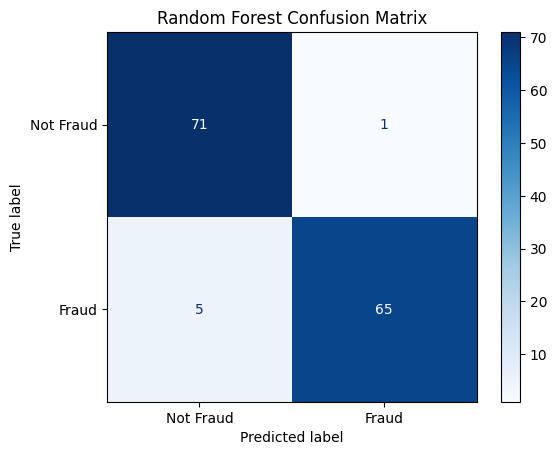

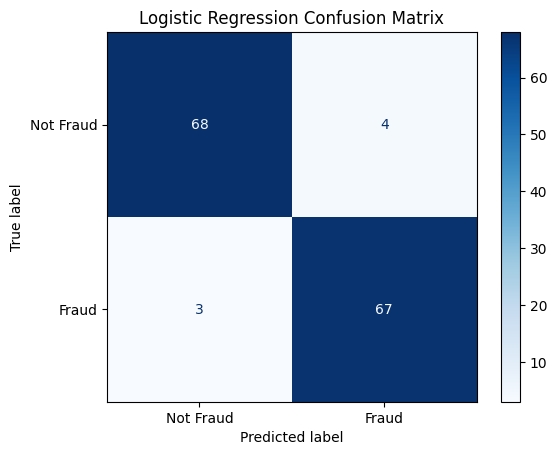

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_val_b, rf_b.predict(x_val_b))
cm_rf_display = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Fraud', 'Fraud'])
cm_rf_display.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_val_b, logistic_model_b.predict(x_val_b))
cm_lr_display = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Fraud', 'Fraud'])
cm_lr_display.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# ✅ STEP - 8  Summary of Metrics on Balanced dataset

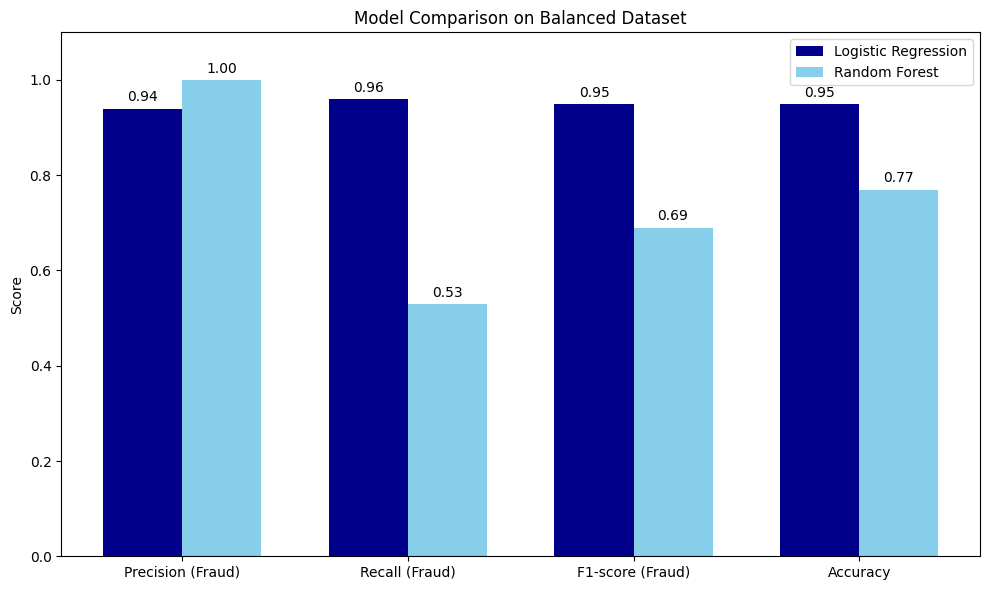

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics for both models
metrics = ['Precision (Fraud)', 'Recall (Fraud)', 'F1-score (Fraud)', 'Accuracy']
logistic_values = [0.94, 0.96, 0.95, 0.95]
random_forest_values = [1.00, 0.53, 0.69, 0.77]

# Create bar plot
x = np.arange(len(metrics))  # label locations
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, logistic_values, width, label='Logistic Regression', color='darkblue')
bars2 = ax.bar(x + width/2, random_forest_values, width, label='Random Forest', color='skyblue')

# Add labels and title
ax.set_ylabel('Score')
ax.set_title('Model Comparison on Balanced Dataset')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()




```
# This is formatted as code
```

# ✅STEP 9 - Saving Trained Model with Joblib

In [ ]:
import joblib

# Save the best model
joblib.dump(rf_b, 'random_forest_model.pkl')  # or logistic_model_b


['random_forest_model.pkl']

In [ ]:
import joblib

# Load the saved Random Forest model
loaded_rf_model = joblib.load('random_forest_model.pkl')

# Now you can use the model to make predictions
predictions = loaded_rf_model.predict(x_val_b)  # Use validation or test data here

# Displaying the classification report
from sklearn.metrics import classification_report
print(classification_report(y_val_b, predictions, target_names=['Not Fraud', 'Fraud']))


              precision    recall  f1-score   support

   Not Fraud       0.93      0.99      0.96        72
       Fraud       0.98      0.93      0.96        70

    accuracy                           0.96       142
   macro avg       0.96      0.96      0.96       142
weighted avg       0.96      0.96      0.96       142



In [ ]:
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
# Assuming you used StandardScaler() before training
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

# Load the scaler used during training
scaler = joblib.load('scaler.pkl')  # Only if you saved it

# Example raw input
raw_input = [[1200.5, 1, 12345] + [0] * 27]  # raw features

# Apply scaling
scaled_input = scaler.transform(raw_input)

# Predict
loaded_rf_model = joblib.load('random_forest_model.pkl')
prediction = loaded_rf_model.predict(scaled_input)

print("Predicted class:", prediction)


Predicted class: [0]


In [ ]:
# Scale the entire dataset (e.g., X_test or X_val)
scaled_data = scaler.transform(x_val)

# Predict on the dataset
predictions = loaded_rf_model.predict(scaled_data)

# Find indices of fraudulent transactions
fraud_indices = np.where(predictions == 1)

# Print the fraudulent samples
print("Fraudulent Transactions:")
print(x_val[fraud_indices])


Fraudulent Transactions:
[[-1.78315838 -1.46250556  2.72159691 ... -0.65235993 -4.3603964
  -0.34739854]
 [-1.25971545 -5.41909027 -6.0483967  ... -3.33850665  4.87952138
   0.70827061]
 [ 0.92498733 -9.1596786  -8.75584623 ... -3.31763924 19.74015336
   1.36653987]
 ...
 [-1.45130213 -4.18711514 -2.85899916 ...  5.6497176  -4.55592749
  -0.03323541]
 [-0.994984   -0.63380108  1.28781301 ...  0.30304891  0.05985041
  -0.34739854]
 [-1.33481777  0.59368539  0.74010192 ...  0.13508764  0.2608484
  -0.34739854]]


In [ ]:
from google.colab import files
files.download('random_forest_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('scaler.pkl')  # only if you used scaling


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>